# TASK : 1

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
print("OpenCV:", cv2.__version__)

OpenCV: 5.0.0


In [14]:
image_path = r"D:\Deep_PR-3\images\flower-7543035_640.jpg"

img = cv2.imread(image_path)

print("Shape:", img.shape)
print("Data type:", img.dtype)

Shape: (427, 640, 3)
Data type: uint8


In [15]:
def show(img, title):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

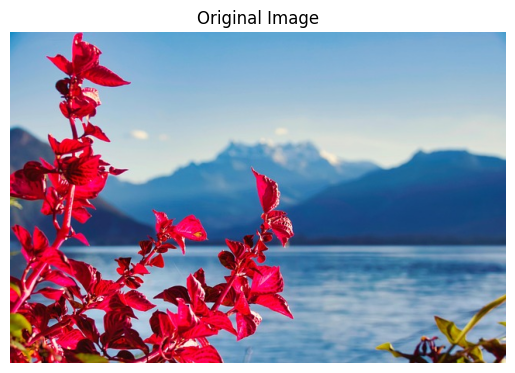

In [16]:
show(img, "Original Image")

Gray Shape: (427, 640)
Gray Data Type: uint8


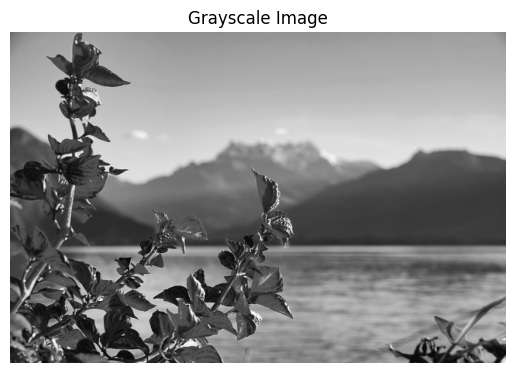

In [17]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Gray Shape:", gray.shape)
print("Gray Data Type:", gray.dtype)

show(gray, "Grayscale Image")

In [18]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

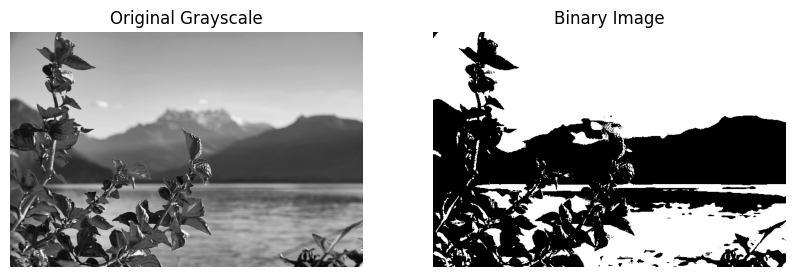

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.show()

In [20]:
kernel = np.ones((5,5), np.uint8)

print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


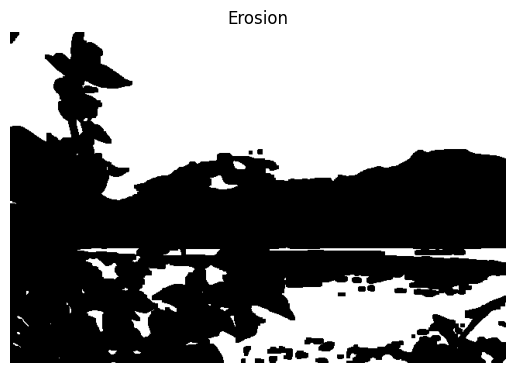

In [21]:
erosion = cv2.erode(binary, kernel)
show(erosion, "Erosion")

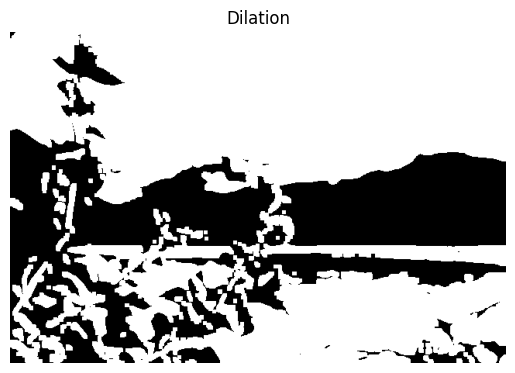

In [22]:
dilation = cv2.dilate(binary, kernel)
show(dilation, "Dilation")

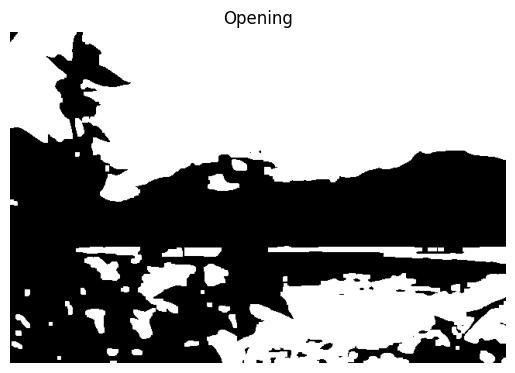

In [23]:
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
show(opening, "Opening")

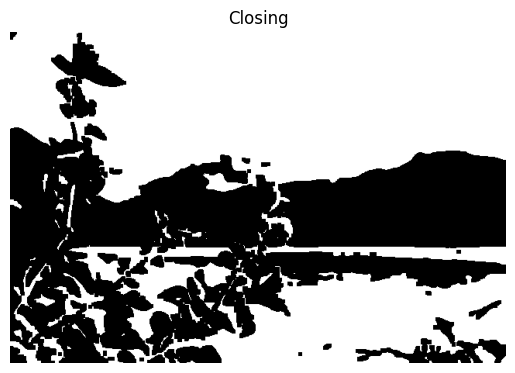

In [24]:
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
show(closing, "Closing")

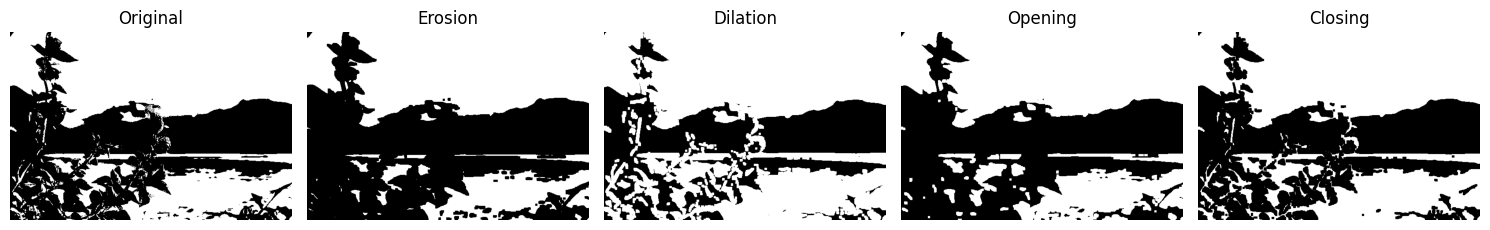

In [25]:
images = [binary, erosion, dilation, opening, closing]
titles = ["Original", "Erosion", "Dilation", "Opening", "Closing"]

plt.figure(figsize=(15,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

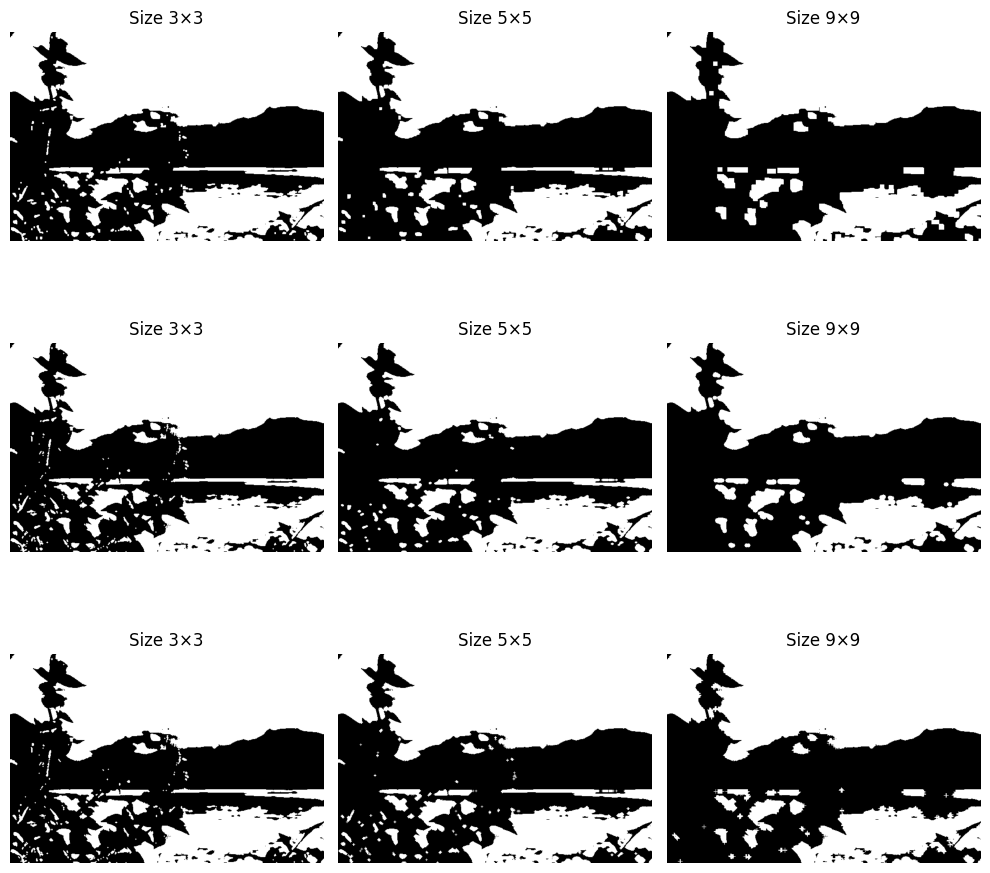

In [26]:
shapes = [
    cv2.MORPH_RECT,
    cv2.MORPH_ELLIPSE,
    cv2.MORPH_CROSS
]

sizes = [3, 5, 9]

plt.figure(figsize=(10,10))

for i, shape in enumerate(shapes):
    for j, size in enumerate(sizes):

        kernel = cv2.getStructuringElement(
            shape, (size, size)
        )

        result = cv2.morphologyEx(
            binary, cv2.MORPH_OPEN, kernel
        )

        plt.subplot(3,3,i*3+j+1)
        plt.imshow(result, cmap="gray")
        plt.title(f"Size {size}×{size}")
        plt.axis("off")

plt.tight_layout()
plt.show()

# 2

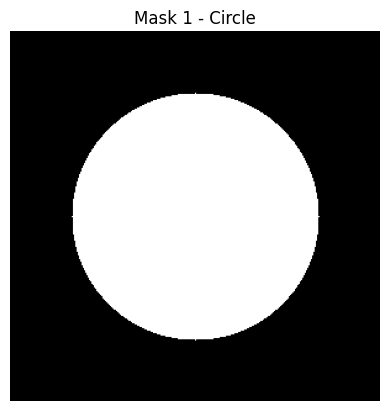

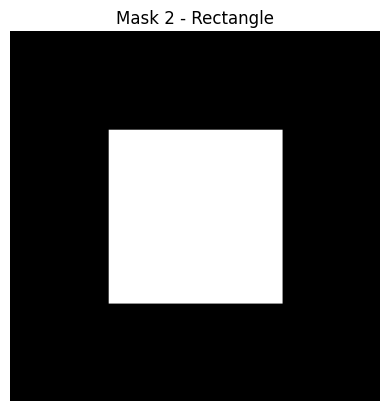

In [27]:
mask1 = np.zeros((300, 300), np.uint8)
mask2 = np.zeros((300, 300), np.uint8)

cv2.circle(mask1, (150,150), 100, 255, -1)
cv2.rectangle(mask2, (80,80), (220,220), 255, -1)

show(mask1, "Mask 1 - Circle")
show(mask2, "Mask 2 - Rectangle")

In [28]:
AND = cv2.bitwise_and(mask1, mask2)
OR = cv2.bitwise_or(mask1, mask2)
XOR = cv2.bitwise_xor(mask1, mask2)
NOT = cv2.bitwise_not(mask1)

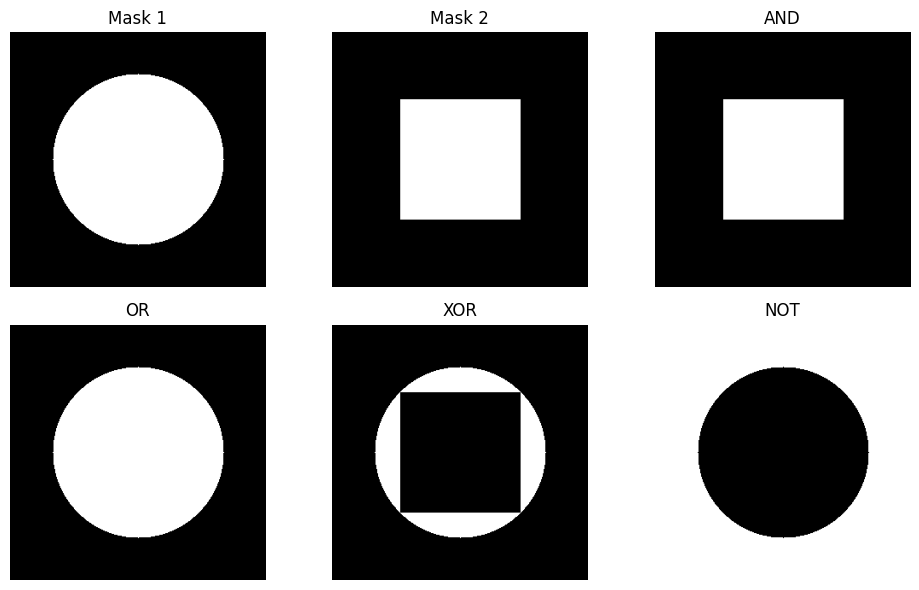

In [29]:
images = [mask1, mask2, AND, OR, XOR, NOT]
titles = ["Mask 1", "Mask 2", "AND", "OR", "XOR", "NOT"]

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

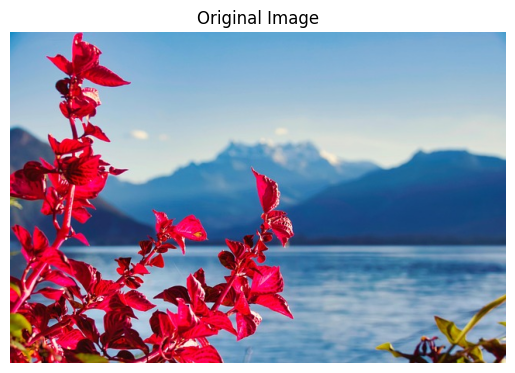

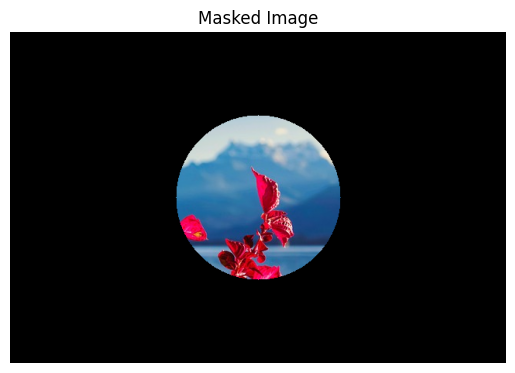

In [30]:
h, w = img.shape[:2]

mask = np.zeros((h, w), np.uint8)

cv2.circle(mask, (w//2, h//2), min(h,w)//4, 255, -1)

masked_image = cv2.bitwise_and(img, img, mask=mask)

show(img, "Original Image")
show(masked_image, "Masked Image")

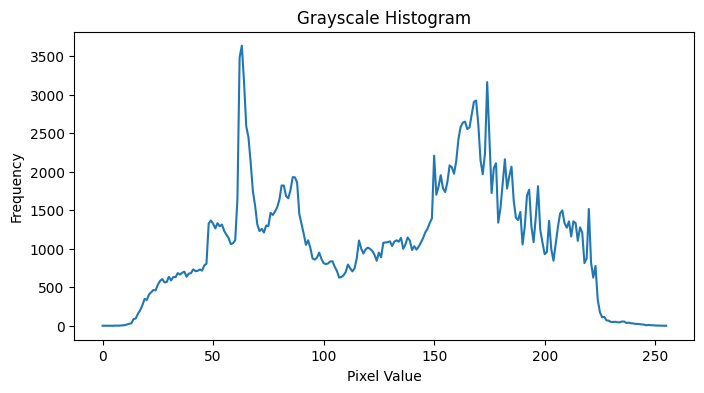

In [31]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray_hist = cv2.calcHist(
    [gray], [0], None, [256], [0,256]
)

plt.figure(figsize=(8,4))
plt.plot(gray_hist)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

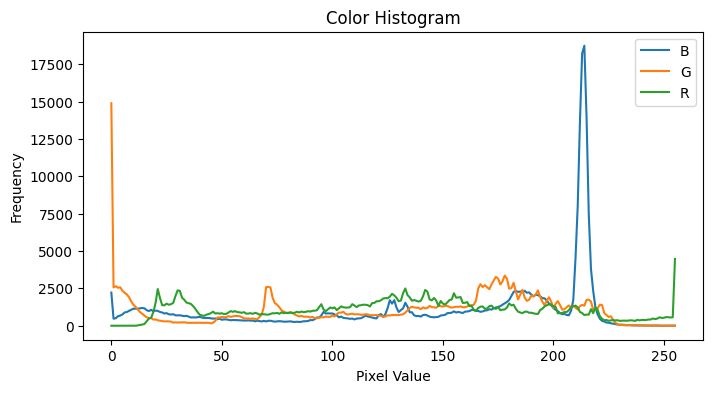

In [32]:
colors = ["b", "g", "r"]

plt.figure(figsize=(8,4))

for i, color in enumerate(colors):
    hist = cv2.calcHist(
        [img], [i], None, [256], [0,256]
    )
    plt.plot(hist, label=color.upper())

plt.title("Color Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [33]:
bright = cv2.convertScaleAbs(
    img, alpha=1.5, beta=30
)

dark = cv2.convertScaleAbs(
    img, alpha=0.7, beta=-30
)

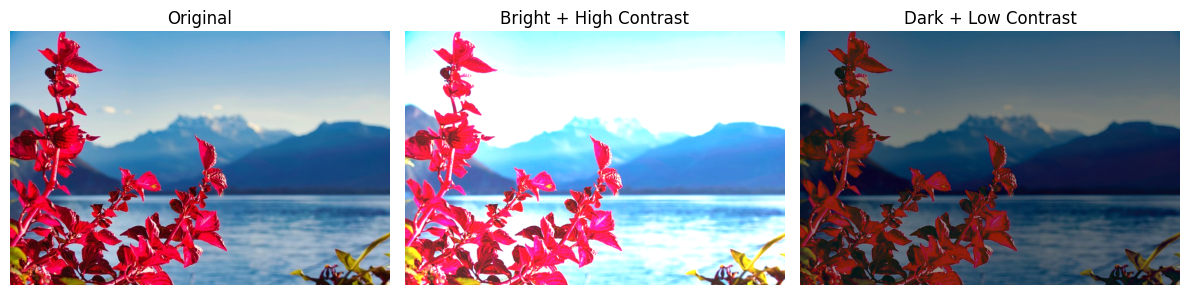

In [34]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(bright, cv2.COLOR_BGR2RGB))
plt.title("Bright + High Contrast")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(dark, cv2.COLOR_BGR2RGB))
plt.title("Dark + Low Contrast")
plt.axis("off")

plt.tight_layout()
plt.show()

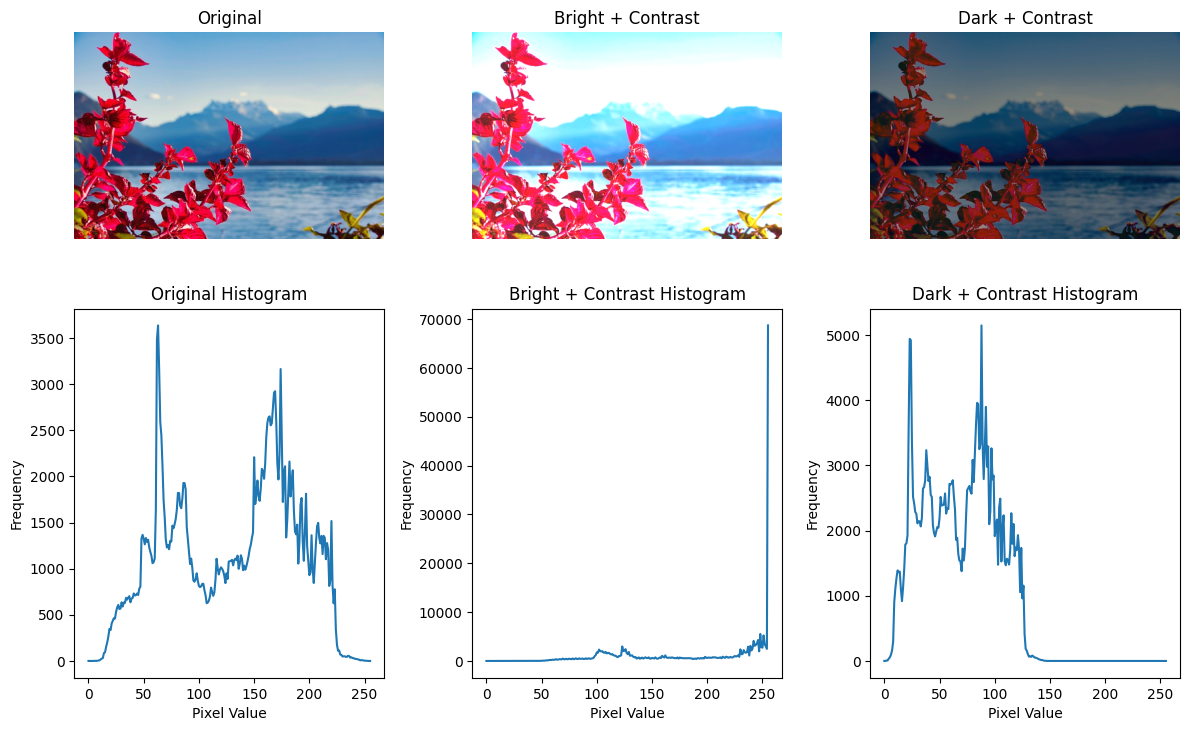

In [35]:
images = [img, bright, dark]
titles = ["Original", "Bright + Contrast", "Dark + Contrast"]

plt.figure(figsize=(12,8))

for i in range(3):

    # Image
    plt.subplot(2,3,i+1)
    
    rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(rgb)
    plt.title(titles[i])
    plt.axis("off")

    # Histogram
    gray_img = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist(
        [gray_img], [0], None, [256], [0,256]
    )

    plt.subplot(2,3,i+4)
    plt.plot(hist)
    plt.title(titles[i] + " Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 3

In [36]:
YUNET_PATH = r"D:\Deep_Learning\PR-3\Models\face_detection_yunet_2023mar.onnx"

In [37]:
import os

print(os.path.exists(YUNET_PATH))

True


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Purvi\AppData\Local\Temp\ipykernel_11156\1195681300.py:1: SyntaxWarning: invalid escape sequence '\D'
  face_img = cv2.imread("D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.22.24 PM.jpeg")


Shape: (1280, 960, 3)


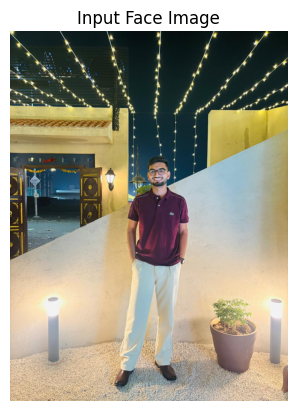

In [37]:
face_img = cv2.imread("D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.22.24 PM.jpeg")

print("Shape:", face_img.shape)

show(face_img, "Input Face Image")

In [38]:
import os

print("Path:", YUNET_PATH)
print("Exists:", os.path.exists(YUNET_PATH))
print("Size:", os.path.getsize(YUNET_PATH), "bytes")

Path: D:\Deep_Learning\PR-3\Models\face_detection_yunet_2023mar.onnx
Exists: True
Size: 232589 bytes


In [39]:
h, w = face_img.shape[:2]

detector = cv2.FaceDetectorYN_create(
    YUNET_PATH,
    "",
    (w, h),
    0.9
)

detector.setInputSize((w, h))

In [40]:
_, faces = detector.detect(face_img)

print("Faces detected:", 0 if faces is None else len(faces))

Faces detected: 1


In [41]:
def detect_faces(image, threshold=0.9):

    h, w = image.shape[:2]

    detector = cv2.FaceDetectorYN_create(
        YUNET_PATH,
        "",
        (w, h),
        threshold
    )

    detector.setInputSize((w, h))

    _, faces = detector.detect(image)

    output = image.copy()

    if faces is not None:
        for face in faces:

            x, y, fw, fh = face[:4].astype(int)
            score = face[-1]

            # Face box
            cv2.rectangle(
                output,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )

            # 5 landmarks
            points = face[4:14].reshape(5, 2).astype(int)

            for px, py in points:
                cv2.circle(
                    output,
                    (px, py),
                    3,
                    (255, 0, 0),
                    -1
                )

            # Confidence
            cv2.putText(
                output,
                f"{score:.2f}",
                (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    return output, faces

Faces: 1


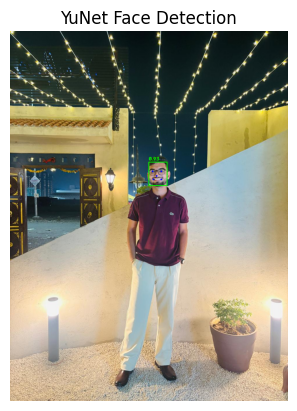

In [42]:
result, faces = detect_faces(face_img)

print("Faces:", 0 if faces is None else len(faces))

show(result, "YuNet Face Detection")

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Purvi\AppData\Local\Temp\ipykernel_11156\202342708.py:2: SyntaxWarning: invalid escape sequence '\D'
  "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.28.09 PM.jpeg",
C:\Users\Purvi\AppData\Local\Temp\ipykernel_11156\202342708.py:3: SyntaxWarning: invalid escape sequence '\D'
  "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.28.21 PM.jpeg",
C:\Users\Purvi\AppData\Local\Temp\ipykernel_11156\202342708.py:4: SyntaxWarning: invalid escape sequence '\D'
  "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.28.10 PM.jpeg",
C:\Users\Purvi\AppData\Local\Temp\ipykernel_11156\202342708.

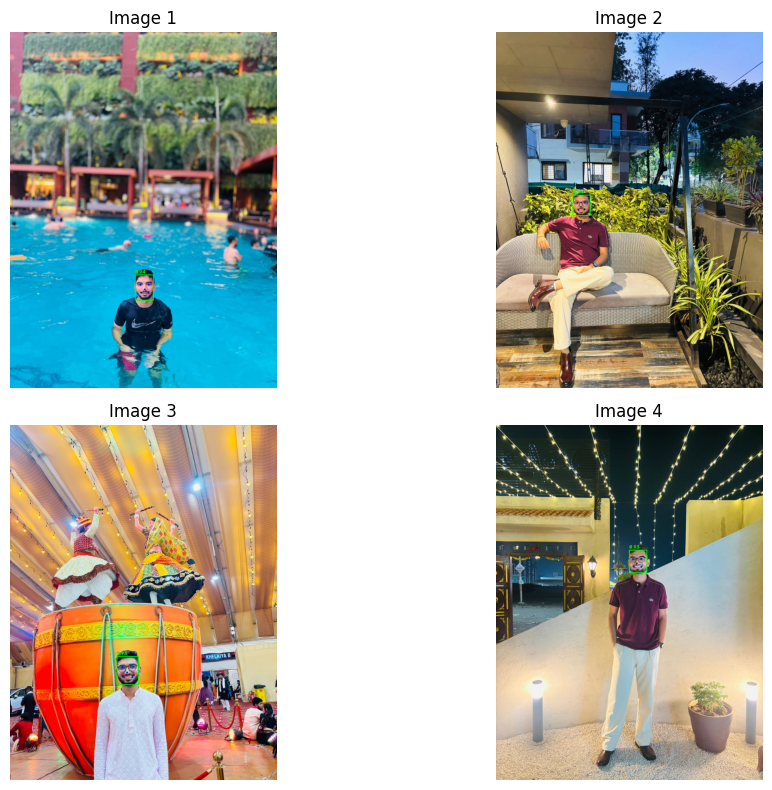

In [44]:
image_paths = [
    "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.28.09 PM.jpeg",
    "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.28.21 PM.jpeg",
    "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.28.10 PM.jpeg",
    "D:\Deep_PR-3\images\WhatsApp Image 2026-10-01 at 3.22.24 PM.jpeg"
]

plt.figure(figsize=(12,8))

for i, path in enumerate(image_paths):

    image = cv2.imread(path)
    result, faces = detect_faces(image)

    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(result)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
import time

cap = cv2.VideoCapture(0)

detector = cv2.FaceDetectorYN_create(
    YUNET_PATH,
    "",
    (640, 480),
    0.7
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    h, w = frame.shape[:2]

    detector.setInputSize((w, h))

    start = time.time()

    _, faces = detector.detect(frame)

    if faces is not None:

        for face in faces:

            x, y, fw, fh = face[:4].astype(int)
            score = face[-1]

            cv2.rectangle(
                frame,
                (x,y),
                (x+fw,y+fh),
                (0,255,0),
                2
            )

            points = face[4:14].reshape(5,2).astype(int)

            for px, py in points:
                cv2.circle(
                    frame,
                    (px,py),
                    3,
                    (255,0,0),
                    -1
                )

            cv2.putText(
                frame,
                f"{score:.2f}",
                (x,y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )

    fps = 1 / (time.time() - start)

    cv2.putText(
        frame,
        f"FPS: {fps:.1f}",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,255),
        2
    )

    cv2.imshow("YuNet Face Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

Threshold: 0.5 Faces: 1


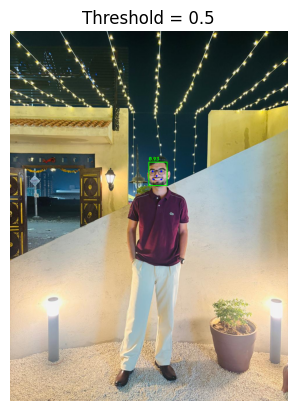

Threshold: 0.7 Faces: 1


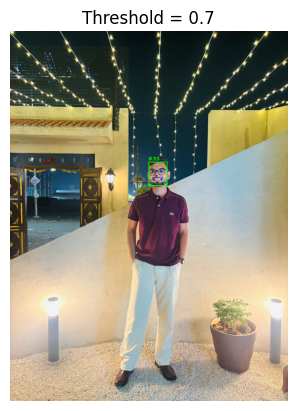

Threshold: 0.9 Faces: 1


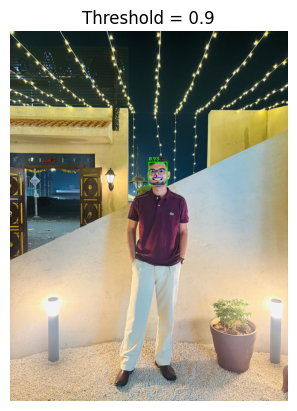

In [46]:
thresholds = [0.5, 0.7, 0.9]

for threshold in thresholds:

    result, faces = detect_faces(
        face_img,
        threshold
    )

    count = 0 if faces is None else len(faces)

    print(
        "Threshold:",
        threshold,
        "Faces:",
        count
    )

    show(
        result,
        f"Threshold = {threshold}"
    )

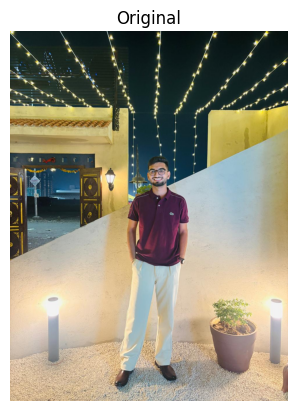

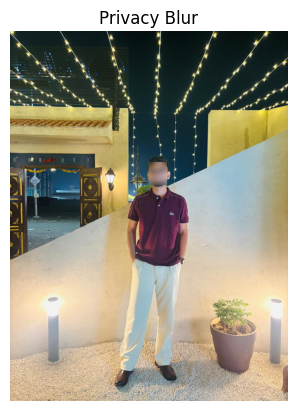

In [47]:
blurred = face_img.copy()

result, faces = detect_faces(face_img, 0.7)

if faces is not None:

    for face in faces:

        x, y, w, h = face[:4].astype(int)

        face_area = blurred[y:y+h, x:x+w]

        face_area = cv2.GaussianBlur(
            face_area,
            (51,51),
            0
        )

        blurred[y:y+h, x:x+w] = face_area

show(face_img, "Original")
show(blurred, "Privacy Blur")

YuNet is a compact CNN-based face detector designed for fast
face detection.

It can detect faces and return five facial landmarks in a
single forward pass.

The score threshold controls the balance between missed
detections and false positives.

A low threshold can detect more faces but may produce false
positives. A high threshold gives more reliable detections but
may miss small, blurry or partially visible faces.

For a real-time security camera, a moderate threshold such as
0.7 provides a good balance between speed and detection.
For offline photo tagging, a higher threshold such as 0.9 can
be used when precision is more important.

# 4

In [55]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [56]:
model = YOLO("yolov8n.pt")

print("YOLOv8n model loaded successfully!")

YOLOv8n model loaded successfully!


In [58]:
image = cv2.imread(r"D:\Deep_PR-3\images\set-various-animals-objects_1308-77010.avif")



In [59]:
results = model(image)

print("Detection completed!")

WARNING 'source' is missing. Using 'source=C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets'.

image 1/2 C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 126.1ms
image 2/2 C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets\zidane.jpg: 384x640 2 persons, 1 tie, 65.2ms
Speed: 9.6ms preprocess, 95.6ms inference, 10.2ms postprocess per image at shape (1, 3, 384, 640)
Detection completed!


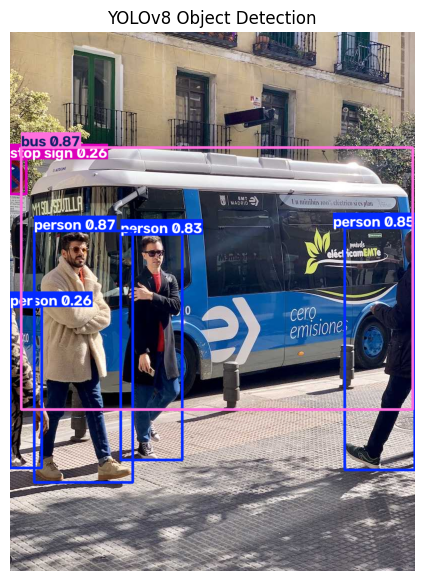

In [60]:
result_image = results[0].plot()

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 Object Detection")
plt.show()

In [61]:
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    
    print(model.names[cls], ":", round(conf, 2))

bus : 0.87
person : 0.87
person : 0.85
person : 0.83
person : 0.26
stop sign : 0.26


WARNING 'source' is missing. Using 'source=C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets'.

image 1/2 C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 59.6ms
image 2/2 C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets\zidane.jpg: 384x640 2 persons, 1 tie, 32.9ms
Speed: 2.1ms preprocess, 46.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


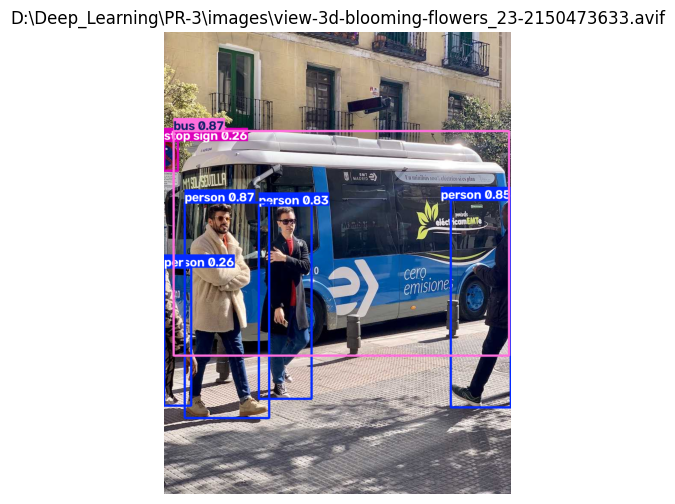


0: 640x576 1 knife, 2 spoons, 2 bowls, 1 orange, 1 potted plant, 1 dining table, 1 cell phone, 62.3ms
Speed: 4.1ms preprocess, 62.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 576)


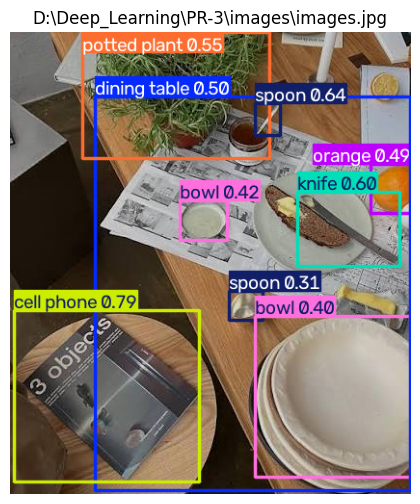

WARNING 'source' is missing. Using 'source=C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets'.

image 1/2 C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 60.9ms
image 2/2 C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ultralytics\assets\zidane.jpg: 384x640 2 persons, 1 tie, 39.5ms
Speed: 2.0ms preprocess, 50.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


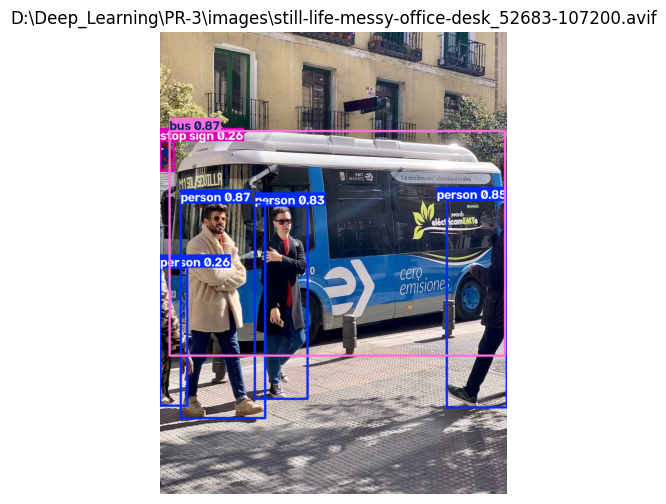

In [62]:
image_paths = [
    r"D:\Deep_Learning\PR-3\images\view-3d-blooming-flowers_23-2150473633.avif",
    r"D:\Deep_Learning\PR-3\images\images.jpg",
    r"D:\Deep_Learning\PR-3\images\still-life-messy-office-desk_52683-107200.avif"
]

for path in image_paths:
    image = cv2.imread(path)
    results = model(image)
    
    output = results[0].plot()
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(path)
    plt.show()

In [63]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    
    if not ret:
        break
    
    results = model(frame, verbose=False)
    output = results[0].plot()
    
    cv2.imshow("YOLOv8 Webcam", output)
    
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


0: 640x576 1 knife, 2 spoons, 2 bowls, 1 orange, 1 potted plant, 1 dining table, 1 cell phone, 131.6ms
Speed: 3.8ms preprocess, 131.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 576)


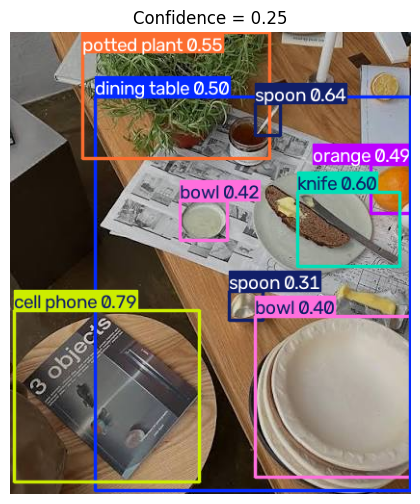


0: 640x576 1 knife, 1 spoon, 1 potted plant, 1 cell phone, 60.6ms
Speed: 2.6ms preprocess, 60.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 576)


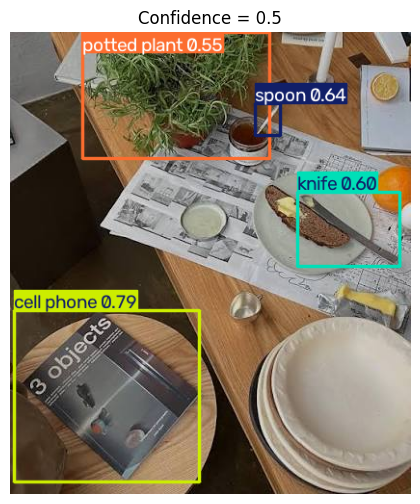


0: 640x576 1 cell phone, 53.5ms
Speed: 2.5ms preprocess, 53.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)


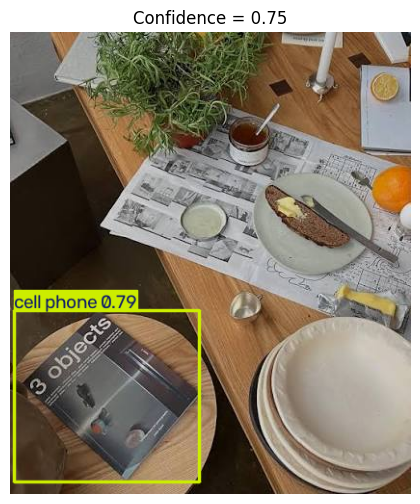

In [64]:
image = cv2.imread(r"D:\Deep_Learning\PR-3\images\images.jpg")

conf_values = [0.25, 0.50, 0.75]

for conf in conf_values:
    
    results = model(image, conf=conf)
    output = results[0].plot()
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Confidence = {conf}")
    plt.show()


0: 640x576 1 knife, 2 spoons, 2 bowls, 1 orange, 1 potted plant, 1 dining table, 1 cell phone, 56.1ms
Speed: 3.5ms preprocess, 56.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 576)


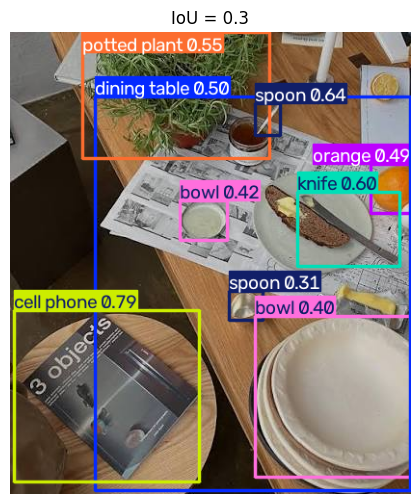


0: 640x576 1 knife, 2 spoons, 2 bowls, 1 orange, 1 potted plant, 1 dining table, 1 cell phone, 51.2ms
Speed: 2.9ms preprocess, 51.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 576)


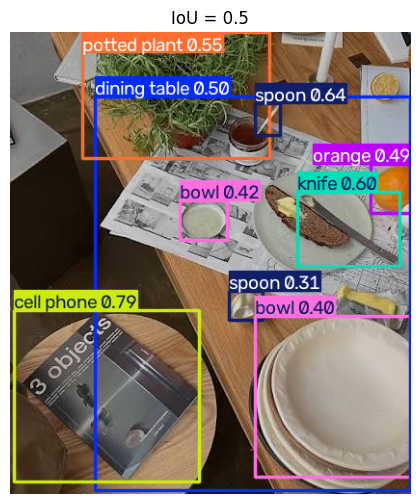


0: 640x576 1 knife, 2 spoons, 2 bowls, 1 orange, 1 potted plant, 1 dining table, 1 cell phone, 46.8ms
Speed: 2.0ms preprocess, 46.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 576)


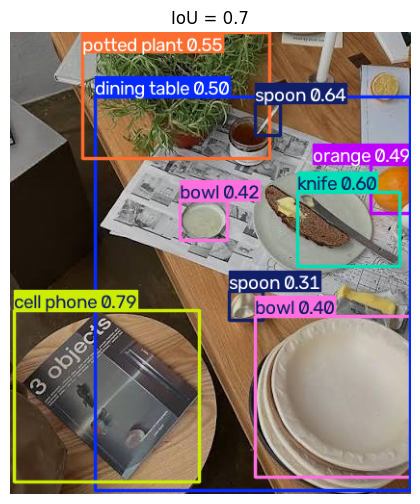

In [65]:
iou_values = [0.30, 0.50, 0.70]

for iou in iou_values:
    
    results = model(image, conf=0.25, iou=iou)
    output = results[0].plot()
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"IoU = {iou}")
    plt.show()

In [66]:
from collections import Counter

image = cv2.imread(r"D:\Deep_Learning\PR-3\images\images.jpg")

results = model(image)

classes = []

for box in results[0].boxes:
    cls = int(box.cls[0])
    classes.append(model.names[cls])

count = Counter(classes)

print("Per-Class Detection Summary:")

for name, number in count.items():
    print(name, ":", number)


0: 640x576 1 knife, 2 spoons, 2 bowls, 1 orange, 1 potted plant, 1 dining table, 1 cell phone, 59.6ms
Speed: 4.6ms preprocess, 59.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 576)
Per-Class Detection Summary:
cell phone : 1
spoon : 2
knife : 1
potted plant : 1
dining table : 1
orange : 1
bowl : 2


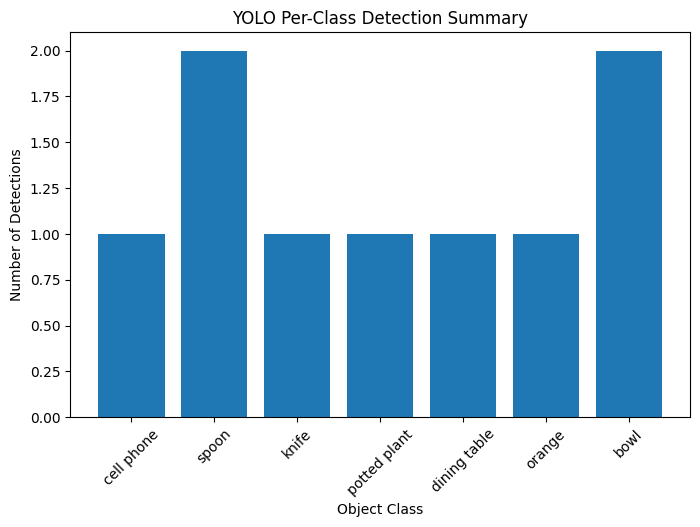

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(count.keys(), count.values())

plt.xlabel("Object Class")
plt.ylabel("Number of Detections")
plt.title("YOLO Per-Class Detection Summary")

plt.xticks(rotation=45)
plt.show()

# 5

In [68]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

In [69]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0

In [70]:
print("YOLO model ready")

YOLO model ready


In [71]:
YUNET_PATH = r"D:\Deep_Learning\PR-3\Models\face_detection_yunet_2023mar.onnx"

In [72]:
h, w = face_img.shape[:2]

detector = cv2.FaceDetectorYN_create(
    YUNET_PATH,
    "",
    (w, h),
    0.9
)

detector.setInputSize((w, h))

print("YuNet detector ready")

YuNet detector ready


In [73]:
def combined_detection(frame):
    
    output = frame.copy()
    
    # ---------- YuNet Face Detection ----------
    h, w = frame.shape[:2]
    detector.setInputSize((w, h))
    
    _, faces = detector.detect(frame)
    
    if faces is not None:
        for face in faces:
            
            x, y, fw, fh = face[:4].astype(int)
            confidence = face[-1]
            
            cv2.rectangle(
                output,
                (x, y),
                (x + fw, y + fh),
                (0, 255, 0),
                2
            )
            
            cv2.putText(
                output,
                f"Face {confidence:.2f}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )
    
    # ---------- YOLO Object Detection ----------
    results = model(frame, verbose=False)
    output = results[0].plot(img=output)
    
    return output

In [74]:
cap = cv2.VideoCapture(0)

while True:
    
    ret, frame = cap.read()
    
    if not ret:
        break
    
    output = combined_detection(frame)
    
    cv2.imshow("YuNet + YOLOv8", output)
    
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

In [75]:
kernel = np.ones((3, 3), np.uint8)

def morphological_opening(frame):
    return cv2.morphologyEx(
        frame,
        cv2.MORPH_OPEN,
        kernel
    )

In [76]:
cap = cv2.VideoCapture(0)

for i in range(100):
    
    ret, frame = cap.read()
    
    if not ret:
        break
    
    # Original
    original_result = combined_detection(frame)
    
    # Morphological opening
    cleaned = morphological_opening(frame)
    cleaned_result = combined_detection(cleaned)
    
    cv2.imshow("Original + Detection", original_result)
    cv2.imshow("Morphological Opening + Detection", cleaned_result)
    
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

In [77]:
cap = cv2.VideoCapture(0)

frames = []

for i in range(100):
    
    ret, frame = cap.read()
    
    if not ret:
        break
    
    frames.append(frame.copy())

cap.release()

print("Frames captured:", len(frames))

Frames captured: 100


In [78]:
start = time.time()

for frame in frames:
    
    h, w = frame.shape[:2]
    
    detector.setInputSize((w, h))
    _, faces = detector.detect(frame)

end = time.time()

yunet_time = end - start
yunet_fps = len(frames) / yunet_time

print("YuNet FPS:", round(yunet_fps, 2))

YuNet FPS: 42.33


In [79]:
start = time.time()

for frame in frames:
    
    results = model(frame, verbose=False)

end = time.time()

yolo_time = end - start
yolo_fps = len(frames) / yolo_time

print("YOLO FPS:", round(yolo_fps, 2))

YOLO FPS: 18.69


In [80]:
start = time.time()

for frame in frames:
    
    combined_detection(frame)

end = time.time()

combined_time = end - start
combined_fps = len(frames) / combined_time

print("Combined FPS:", round(combined_fps, 2))

Combined FPS: 12.89


In [81]:
print("----- FPS BENCHMARK -----")
print("YuNet FPS     :", round(yunet_fps, 2))
print("YOLO FPS      :", round(yolo_fps, 2))
print("Combined FPS  :", round(combined_fps, 2))

----- FPS BENCHMARK -----
YuNet FPS     : 42.33
YOLO FPS      : 18.69
Combined FPS  : 12.89


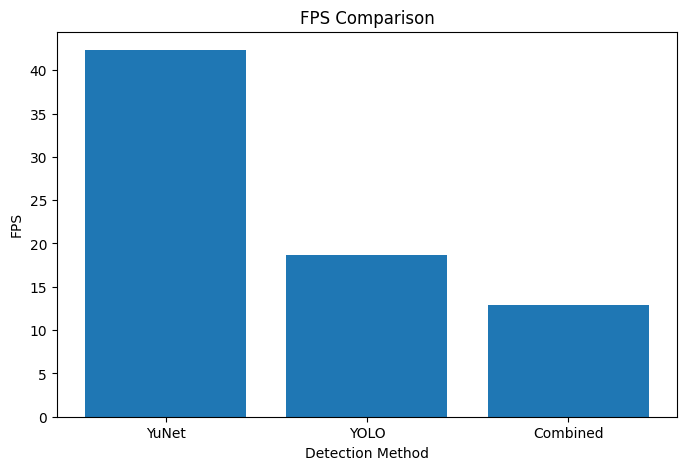

In [82]:
methods = ["YuNet", "YOLO", "Combined"]
fps_values = [yunet_fps, yolo_fps, combined_fps]

plt.figure(figsize=(8, 5))

plt.bar(methods, fps_values)

plt.xlabel("Detection Method")
plt.ylabel("FPS")
plt.title("FPS Comparison")

plt.show()

## Reflection

The best combination for a real-time monitoring application was
YuNet for face detection and YOLOv8n for general object detection.
YuNet is lightweight and provides fast face detection, while YOLOv8n
can detect multiple object classes.

Morphological opening can be useful when the input contains small
noise, but excessive preprocessing may remove useful image details.
Therefore, a light preprocessing step is preferred.

For a low-power device, I would prefer YOLOv8n because it is a small
YOLO model and provides a good balance between speed and accuracy.
If higher accuracy is required and more computational resources are
available, a larger YOLO model could be considered.

Another possible improvement would be changing the confidence
threshold. A lower threshold can detect more objects but may produce
more false detections, while a higher threshold can reduce false
detections but may miss some objects.